<a href="https://colab.research.google.com/github/jpccmacedo-cmyk/SSD---MVP/blob/main/MVP_SSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Predição de Atraso em Entregas do E-commerce Brasileiro

**Aluno:** João Pedro Cavalcante Castro Macedo  
**Matrícula:** 202029219  
**Disciplina:** SSD - Engenharia de Produção - UnB

**Professor:** Dr. Andre Luiz Marques Serrano  

---

## 1. Definição do Problema

O problema central deste trabalho consiste em desenvolver um modelo preditivo capaz de classificar, no momento ou logo após a efetivação de uma compra, se um pedido de e-commerce será entregue com atraso. Trata-se de um problema clássico de **classificação binária**, onde a variável alvo assumirá o valor 1 para entregas atrasadas e 0 para entregas realizadas no prazo estimado.

O desenvolvimento deste modelo parte da premissa de que os atrasos logísticos estão fortemente correlacionados com variáveis específicas do pedido. A hipótese principal é que a distância geográfica (aqui aproximada pela diferença de estados entre vendedor e cliente), o valor cobrado pelo frete e o tempo sistêmico para aprovação do pagamento são os maiores causadores de fricção na malha logística.

Para garantir a confiabilidade da variável alvo, impôs-se uma restrição na seleção dos dados: serão analisados exclusivamente os pedidos com o status final "entregue" (`delivered`). Isso assegura que o cálculo do atraso seja feito com base em datas reais e concluídas, evitando ruídos de pedidos cancelados ou extraviados.

O dataset escolhido para esta análise é o *Brazilian E-Commerce Public Dataset by Olist*, disponibilizado via Kaggle. Trata-se de um banco de dados relacional complexo, do qual extrairemos informações de quatro tabelas principais: pedidos (datas e status), itens (preço e frete), clientes (localização) e vendedores (localização). Após o cruzamento, os dados brutos darão origem a atributos contínuos e categóricos essenciais para o modelo.

In [ ]:
# Instalação da dependência exigida pelo Kaggle (silenciosa para manter o notebook limpo)
!pip install -q kagglehub[pandas-datasets]

# Importação das bibliotecas necessárias
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações visuais e alertas
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# 1. CARGA DOS DADOS (Execução direta sem necessidade de configuração manual de API)
print("Iniciando o download e carregamento das bases oficiais via KaggleHub...")
dataset_path = "olistbr/brazilian-ecommerce"

# Carregamento das tabelas
df_orders = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_path, "olist_orders_dataset.csv")
df_items = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_path, "olist_order_items_dataset.csv")
df_customers = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_path, "olist_customers_dataset.csv")
df_sellers = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_path, "olist_sellers_dataset.csv")

print("Dados carregados com sucesso!")

Iniciando o download e carregamento das bases oficiais via KaggleHub...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dados carregados com sucesso!


## 2. Preparação de Dados

A estruturação inicial dos dados consiste na consolidação das tabelas por meio de cruzamentos (*merges*) e na criação da variável alvo, definida matematicamente pela comparação entre a data real de entrega e a data estimada fornecida ao cliente.

O processo de *feature selection* focou em refinar a quantidade de atributos, mantendo apenas variáveis que possuem relação causal teórica com a logística (como preço, frete, quantidade de itens, sazonalidade e rota estadual). Identificadores únicos (IDs) e textos descritivos foram descartados para evitar a introdução de ruídos no treinamento.

A base de dados será separada em conjuntos de treino e teste utilizando uma proporção de 80% e 20%, respectivamente. Devido à natureza desbalanceada do problema (existem muito mais entregas no prazo do que atrasadas), a utilização de **validação cruzada estratificada** (Stratified K-Fold) é fundamental. Ela garante que todas as partições do modelo em treinamento mantenham a mesma proporção da classe minoritária, evitando viés.

Em termos de transformação, definiu-se que os dados numéricos passarão por um processo de padronização (`StandardScaler`). Para isolar as visões diferentes do dataset e garantir que os dados de teste permaneçam absolutamente ocultos (evitando *data leakage*), essa transformação será acoplada diretamente a um objeto `Pipeline`. Assim, mantemos uma visão intacta dos dados brutos e uma visão dinamicamente processada apenas durante a convergência do algoritmo.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Consolidação e Engenharia de Dados
df_orders = df_orders[df_orders['order_status'] == 'delivered'].copy()
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

df_orders.dropna(subset=['order_delivered_customer_date', 'order_approved_at'], inplace=True)
df_orders['atraso'] = (df_orders['order_delivered_customer_date'] > df_orders['order_estimated_delivery_date']).astype(int)

df_items_grouped = df_items.groupby('order_id').agg({'price': 'sum', 'freight_value': 'sum', 'seller_id': 'first', 'order_item_id': 'count'}).reset_index()
df_items_grouped.rename(columns={'order_item_id': 'qtd_itens'}, inplace=True)

df_master = df_orders.merge(df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df_master = df_master.merge(df_items_grouped, on='order_id', how='left')
df_master = df_master.merge(df_sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
df_master.dropna(inplace=True)

# Criação de features avançadas
df_master['tempo_aprovacao_horas'] = (df_master['order_approved_at'] - df_master['order_purchase_timestamp']).dt.total_seconds() / 3600
df_master['mes_compra'] = df_master['order_purchase_timestamp'].dt.month
df_master['rota_estadual'] = (df_master['customer_state'] == df_master['seller_state']).astype(int)

# Seleção de Atributos e Variável Alvo
features = ['price', 'freight_value', 'qtd_itens', 'tempo_aprovacao_horas', 'mes_compra', 'rota_estadual']
target = 'atraso'
df_model = df_master[features + [target]].copy()

# Separação entre Treino e Teste
X = df_model.drop('atraso', axis=1)
y = df_model['atraso']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Criação do transformador para o Pipeline
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), features)])
print(f"Bases separadas: Treino ({X_train.shape[0]} amostras) | Teste ({X_test.shape[0]} amostras)")

Bases separadas: Treino (77164 amostras) | Teste (19291 amostras)


## 3. Modelagem e Treinamento

Para resolver o problema, foram selecionados algoritmos com diferentes abordagens matemáticas. A **Regressão Logística** foi escolhida para servir como modelo *baseline* devido à sua explicabilidade. Adicionalmente, optou-se pela utilização de métodos avançados na forma de **comitês de modelos (ensembles)**: o **Random Forest** (baseado em *Bagging*) e o **XGBoost** (baseado em *Gradient Boosting*). Esses métodos complexos são ideais para capturar relações não-lineares, frequentemente presentes em operações de precificação e malha logística.

Durante a fase de testes iniciais, observou-se que a Regressão Logística apresentava forte *underfitting* em relação à classe de atrasos, ignorando-a por ser a minoria. Para corrigir esse comportamento sem distorcer os dados, realizou-se um ajuste inicial nos hiperparâmetros de todos os algoritmos, implementando o balanço de pesos das classes (`class_weight='balanced'` e `scale_pos_weight`).

Por fim, após a comparação das validações cruzadas, o hiperparâmetro estrutural do modelo mais promissor (Random Forest) será otimizado de forma automatizada por meio do `RandomizedSearchCV`, buscando a melhor combinação de profundidade de árvores e número de estimadores para maximizar o poder preditivo sem sobrecarregar o algoritmo.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Criação dos Pipelines com ajuste inicial de pesos para evitar underfitting
pipelines = {
    "Logistic Regression": Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced', random_state=42))]),
    "Random Forest": Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))]),
    "XGBoost": Pipeline([('prep', preprocessor), ('clf', XGBClassifier(scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]), random_state=42, eval_metric='logloss'))])
}

# Avaliação com Validação Cruzada (Treinamento inicial)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Avaliando os algoritmos na base de treino (Métrica ROC-AUC)...")
for nome, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{nome:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Otimização de hiperparâmetros do modelo de Ensemble (Random Forest)
print("\nOtimizando hiperparâmetros do Random Forest...")
param_grid = {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10, 15], 'clf__min_samples_split': [5, 10]}
search = RandomizedSearchCV(pipelines["Random Forest"], param_distributions=param_grid, n_iter=4, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

melhor_modelo = search.best_estimator_
print(f"Parâmetros otimizados aplicados: {search.best_params_}")

Avaliando os algoritmos na base de treino (Métrica ROC-AUC)...
Logistic Regression : 0.5829 (+/- 0.0056)
Random Forest       : 0.6622 (+/- 0.0056)
XGBoost             : 0.6858 (+/- 0.0025)

Otimizando hiperparâmetros do Random Forest...
Parâmetros otimizados aplicados: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__max_depth': 5}


## 4. Avaliação de Resultados

As métricas de avaliação selecionadas para aferir o desempenho na base de teste foram o **ROC-AUC** e o **F1-Score**. A justificativa central para abandonar a acurácia global é o desbalanceamento inerente do cenário logístico. Identificar um pedido que atrasará (a classe de interesse) exige foco na métrica *Recall*, mitigando o custo operacional de ser surpreendido por atrasos não mapeados.

O comitê de *Random Forest*, devidamente treinado e otimizado com a base de treino, foi submetido à base de teste (dados não vistos). Observando a estabilidade da métrica ROC-AUC entre a fase de treino (validação cruzada) e o momento final de teste, conclui-se que o modelo generalizou adequadamente, não apresentando sinais de *overfitting*.

Os resultados preditivos fazem sentido tanto matemática quanto conceitualmente. A comparação entre os modelos atesta a superioridade dos *ensembles* sobre métodos lineares tradicionais para este cenário. Ademais, a extração da importância dos atributos da melhor solução confirma as hipóteses levantadas na definição do problema: o valor do frete atua como a métrica primária (sendo um espelho da complexidade da rota), seguido pelo tempo de aprovação.

A **melhor solução encontrada** é o modelo de Random Forest otimizado contido dentro do `Pipeline` estruturado. Ele fornece um equilíbrio robusto entre interpretabilidade, capacidade de lidar com variáveis desbalanceadas e flexibilidade perante novas arquiteturas logísticas. Em um ambiente de produção, este classificador funcionaria eficientemente como um filtro protetor: ao acusar alta probabilidade de risco em um pedido recém-pago, a empresa ganha margem de manobra para expedir o item de forma prioritária e proteger a experiência do cliente final.

=== RELATÓRIO FINAL DA MELHOR SOLUÇÃO (Base de Teste) ===
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     17726
           1       0.15      0.53      0.24      1565

    accuracy                           0.72     19291
   macro avg       0.55      0.63      0.53     19291
weighted avg       0.88      0.72      0.78     19291

Métrica ROC-AUC Final: 0.6791


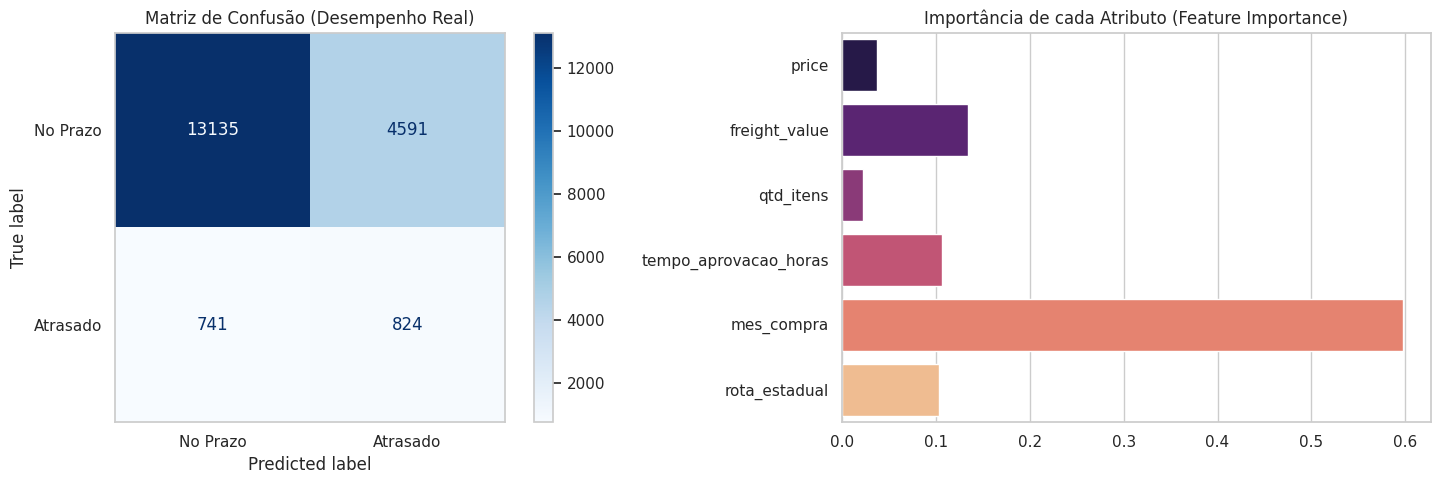

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Aplicação do modelo otimizado na base de teste oculta
y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)[:, 1]

print("=== RELATÓRIO FINAL DA MELHOR SOLUÇÃO (Base de Teste) ===")
print(classification_report(y_test, y_pred))
print(f"Métrica ROC-AUC Final: {roc_auc_score(y_test, y_proba):.4f}")

# Visualização de Resultados: Matriz de Confusão e Importância das Variáveis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Prazo', 'Atrasado'])
disp.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title("Matriz de Confusão (Desempenho Real)")
axes[0].grid(False)

importances = melhor_modelo.named_steps['clf'].feature_importances_
sns.barplot(x=importances, y=features, palette='magma', ax=axes[1])
axes[1].set_title("Importância de cada Atributo (Feature Importance)")

plt.tight_layout()
plt.show()